In [1]:


import os
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

data_folder = '../data/'
path = os.path.join(data_folder)

df = pd.DataFrame()
df2 = pd.DataFrame()
for file in os.listdir(path):
    if 'price_history_full' in file:
        df = pd.read_csv(data_folder + file)
        

launch_path = '../data/official_launch_prices.csv' #added on 26.05
launch_ref = pd.read_csv(launch_path)
launch_ref.head()

df = df.merge(launch_ref, on = 'submodel_name')
# meta_path = '../data/all_asins_meta.csv'
# meta_df = pd.read_csv(meta_path)

df.dtypes
df['official_premiere_date'] = pd.to_datetime(df['official_premiere_date'])
print(df[df['official_launch_price'].isna()]['submodel_name'].unique())



# KEEPA_EPOCH = pd.Timestamp('2011-01-01') #19.05 - - - Not needed anymore, we've already handled it before importing to SQL
# df['listed_since'] = pd.to_datetime(KEEPA_EPOCH + pd.to_timedelta(df['listed_since'], 'minutes'))

df['datetime'] = pd.to_datetime(df['datetime'])
df['days_since_launch'] = (df['datetime'] - df['official_premiere_date']).dt.days
df = df[df['days_since_launch'] > 0]

df['NEW'] = df['new_price'] * 100 #had to implement this here in the new pipeline, as it wasn't handled
df = df.drop('new_price', axis = 1)

df['price_pct_of_launch'] = round(df['NEW'] / df['official_launch_price'] * 100, 1)
df['days_rounded'] = (df['days_since_launch'] / 7).round() * 7


<StringArray>
[]
Length: 0, dtype: str


In [2]:
'''Take Chart 1 (Base iPhones, price decay by generation) and split by `product_grade`.
Two options — pick whichever makes more sense after trying:
'''




'Take Chart 1 (Base iPhones, price decay by generation) and split by `product_grade`.\nTwo options — pick whichever makes more sense after trying:\n'

In [3]:

#Chart 3 - Sales Rank vs Generations (iPhone 13, 14, 15 etc.) + days from premiere
#Created on 25.05, updated on 26.05 to account for THE ACTUAL OFFICIAL PREMIERE DATES (mean of all memory size prices) and launch prices for each submodel
ms_df = pd.read_csv('../data/monthly_sold_full.csv')

ms_df = ms_df.merge(launch_ref, on = 'submodel_name', how = 'left')
ms_df.head()

ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])

del(ms_df['premiere_date']) #deleting it so it doesn't confuse us later - the official premiere date is what matters

ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]

ms_df['tier'] = ms_df.apply(
    lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(),
    axis=1
)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')

print(ms_df['tier'].value_counts())
print(ms_df.head())
print(ms_df.shape)


filtered_df = ms_df[(ms_df['tier'] == 'Base') & (ms_df['brand'] == 'Apple') & (ms_df['monthly_sold'] >= 0)]
filtered_df = filtered_df.groupby(['generation_name', 'days_rounded'])['monthly_sold'].agg('mean').reset_index()
filtered_df.head()
ms_chart = px.line(
    filtered_df,
    x = 'days_rounded',
    y = 'monthly_sold',
    color = 'generation_name',
    title = 'Sales Rank over time - base iPhones across generations (higher = more sold)'
)
ms_chart.update_yaxes(autorange='reversed')
ms_chart.show()


tier
Base        6228
Pro         4007
Pro Max     2309
Ultra       1577
a           1053
FE           965
Mini         781
Plus         737
+            730
Pro Fold      42
Edge          32
Pro XL        24
Name: count, dtype: int64
         asin    product_grade submodel_name  brand generation_name  \
0  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
1  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
2  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
3  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
4  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   

             datetime  monthly_sold  official_launch_price  \
0 2023-10-20 07:04:00            50                    766   
1 2023-11-28 13:34:00           100                    766   
2 2024-01-01 08:42:00            50                    766   
3 2024-01-01 18:16:00           100                    766   
4 2024-01-02 14:56:00       

In [4]:
#Chart 4 - Sales Rank vs Submodels of a given generation (iPhone 13 Base vs Pro vs Pro Max vs Mini etc.) + days from premiere

filtered_df = ms_df[ms_df['generation_name'] == 'iPhone 13']
filtered_df = filtered_df.groupby(['submodel_name', 'days_rounded'])['monthly_sold'].agg('mean').reset_index()
filtered_df.head()

submodels_ms_chart = px.line(
    filtered_df,
    x = 'days_rounded',
    y = 'monthly_sold',
    color = 'submodel_name',
    title = 'Sales Rank over time - iPhone 13 submodels (lower rank = more sold)'
)
submodels_ms_chart.update_yaxes(autorange = 'reversed')
submodels_ms_chart.show()


In [5]:
#Chart 5 - Sales Rank vs Generations (iPhone 13, 14, 15 etc.) + actual datetimes

ms_df = pd.read_csv('../data/monthly_sold_full.csv')

ms_df = ms_df.merge(launch_ref, on = 'submodel_name', how = 'left')
ms_df.head()

ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])

del(ms_df['premiere_date']) #deleting it so it doesn't confuse us later - the official premiere date is what matters

ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]

ms_df['tier'] = ms_df.apply(
    lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(),
    axis=1
)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')

print(ms_df['tier'].value_counts())
print(ms_df.head())
print(ms_df.shape)



filtered_df = ms_df[(ms_df['tier'] == 'Base') & (ms_df['brand'] == 'Apple') & (ms_df['monthly_sold'] >= 0)]
filtered_df = (filtered_df
    .set_index('datetime')
    .groupby('generation_name')
    .resample('W')['monthly_sold']
    .mean()
    .reset_index()
)
filtered_df['monthly_sold'] = filtered_df.groupby('generation_name')['monthly_sold'].ffill()


filtered_df.head()
ms_chart = px.line(
    filtered_df,
    x = 'datetime',
    y = 'monthly_sold',
    color = 'generation_name',
    title = 'Sales Rank over time - base iPhones across generations (higher = more sold)'
)
ms_chart.update_yaxes(autorange='reversed')

for year in range(2022, 2025):
    ms_chart.add_vline(x=int(pd.Timestamp(f'{year}-09-15').timestamp() * 1000), line_dash='dot', line_color='gray', annotation_text='Launch')
    ms_chart.add_vline(x=int(pd.Timestamp(f'{year}-11-25').timestamp() * 1000), line_dash='dot', line_color='orange', annotation_text='BF')
    ms_chart.add_vline(x=int(pd.Timestamp(f'{year}-12-20').timestamp() * 1000), line_dash='dot', line_color='red', annotation_text='Xmas')


ms_chart.show()

tier
Base        6228
Pro         4007
Pro Max     2309
Ultra       1577
a           1053
FE           965
Mini         781
Plus         737
+            730
Pro Fold      42
Edge          32
Pro XL        24
Name: count, dtype: int64
         asin    product_grade submodel_name  brand generation_name  \
0  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
1  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
2  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
3  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
4  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   

             datetime  monthly_sold  official_launch_price  \
0 2023-10-20 07:04:00            50                    766   
1 2023-11-28 13:34:00           100                    766   
2 2024-01-01 08:42:00            50                    766   
3 2024-01-01 18:16:00           100                    766   
4 2024-01-02 14:56:00       

In [6]:
#Chart 6 - Sales Rank vs Submodels (iPhone 13 Base vs Pro vs Pro Max etc) + actual datetimes

ms_df = pd.read_csv('../data/monthly_sold_full.csv')

ms_df = ms_df.merge(launch_ref, on = 'submodel_name', how = 'left')
ms_df.head()

ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])

del(ms_df['premiere_date']) #deleting it so it doesn't confuse us later - the official premiere date is what matters

ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]

ms_df['tier'] = ms_df.apply(
    lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(),
    axis=1
)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')

print(ms_df['tier'].value_counts())
print(ms_df.head())
print(ms_df.shape)



filtered_df = ms_df[(ms_df['brand'] == 'Apple') & (ms_df['monthly_sold'] >= 0) & (ms_df['generation_name'] == 'iPhone 13')]
filtered_df = (filtered_df
    .set_index('datetime')
    .groupby('submodel_name')
    .resample('W')['monthly_sold']
    .mean()
    .reset_index()
)
filtered_df['monthly_sold'] = filtered_df.groupby('submodel_name')['monthly_sold'].ffill()


filtered_df.head()
ms_chart = px.line(
    filtered_df,
    x = 'datetime',
    y = 'monthly_sold',
    color = 'submodel_name',
    title = 'Sales Rank over time - iPhone 13 submodels (higher = more sold)'
)
ms_chart.update_yaxes(autorange='reversed')

for year in range(2022, 2025):
    ms_chart.add_vline(x=int(pd.Timestamp(f'{year}-09-15').timestamp() * 1000), line_dash='dot', line_color='gray', annotation_text='Launch')
    ms_chart.add_vline(x=int(pd.Timestamp(f'{year}-11-25').timestamp() * 1000), line_dash='dot', line_color='orange', annotation_text='BF')
    ms_chart.add_vline(x=int(pd.Timestamp(f'{year}-12-20').timestamp() * 1000), line_dash='dot', line_color='red', annotation_text='Xmas')


ms_chart.show()

tier
Base        6228
Pro         4007
Pro Max     2309
Ultra       1577
a           1053
FE           965
Mini         781
Plus         737
+            730
Pro Fold      42
Edge          32
Pro XL        24
Name: count, dtype: int64
         asin    product_grade submodel_name  brand generation_name  \
0  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
1  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
2  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
3  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   
4  B011SDYBZW  Renewed Premium     iPhone 11  Apple       iPhone 11   

             datetime  monthly_sold  official_launch_price  \
0 2023-10-20 07:04:00            50                    766   
1 2023-11-28 13:34:00           100                    766   
2 2024-01-01 08:42:00            50                    766   
3 2024-01-01 18:16:00           100                    766   
4 2024-01-02 14:56:00       

I think Vlines are necessary, but we need to name them properly so they're visible.
Beyond that, this data is really bad as it starts late 2023, so we can't really see the patterns in a proper way.

In [7]:
#W4 D1 T3 //// W4 D2 T3 --- W4 D4 --- 

'''Chart 1
Take Chart 1 (Base iPhones, price decay by generation) and split by `product_grade`.
Two options — pick whichever makes more sense after trying:

'''



df['tier'] = df.apply(
    lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(),
    axis=1
)
df['tier'] = df['tier'].replace('', 'Base')

base_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple')] 
# print(base_df['product_grade'].value_counts())

grouped_base_df = base_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].agg('mean').reset_index()
grade_means = df[
    (df['tier'] == 'Base') & (df['brand'] == 'Apple')
].groupby('product_grade')['price_pct_of_launch'].mean()

renewed_premium_premium = grade_means['Renewed Premium'] - grade_means['Renewed']
print(round(renewed_premium_premium, 1))


line_plot = px.line(
    grouped_base_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch', 
    color = 'generation_name',
    line_dash = 'product_grade',
    title = 'Price decay - Base models across generations'
)
line_plot.add_hline(y = 50)
line_plot.show()

10.2


In [8]:
#W4 D1 T4
'''Pick one generation with multiple tiers (e.g. iPhone 13 — has Base, Mini, Pro, Pro Max).
Filter `df` to that generation_name.
Groupby `submodel_name + days_rounded` → mean `price_pct_of_launch`.
Plot Plotly line: x = days_rounded, y = price_pct_of_launch, color = submodel_name.
Add hline at y=50. Title: "Price Decay — [generation] by submodel".

Does the Pro Max hold value better than the base model? Does the Mini decay faster?'''

generation_df = df[df['generation_name'] == 'iPhone 13']
grouped_generation_decay_df = generation_df.groupby(['submodel_name', 'days_rounded'])['price_pct_of_launch'].agg('mean').reset_index()

grouped_generation_decay_chart = px.line(
    grouped_generation_decay_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch',
    color = 'submodel_name',
    title = 'Price decay - Iphone 13 by submodels'
)
grouped_generation_decay_chart.add_hline(y = 50)
grouped_generation_decay_chart.show()

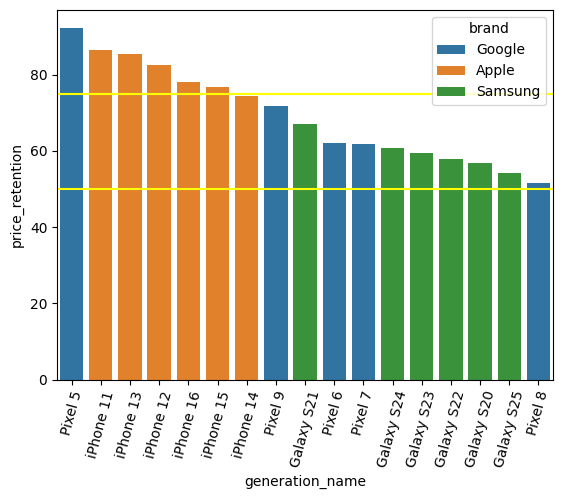

In [9]:
#Chart 7 - Brand comparison at FULL YEAR
'''
Using the resampled `df` from 04_interactive_charts.ipynb:

1. Filter to `days_since_launch` between 330 and 400 (window around 1 year)
   — this gives enough data points per generation without being too narrow
2. Groupby `generation_name` → mean `price_pct_of_launch` and first `brand`
   Use named agg:
   ```python
   comparison_df = filtered.groupby('generation_name').agg(
       retention=('price_pct_of_launch', 'mean'),
       brand=('brand', 'first')
   ).reset_index()
   ```
3. Sort by `retention` descending
4. Exclude generations with <50 rows in the window (too sparse — print which ones)
5. Seaborn barplot:
   - x = `generation_name`, y = `retention`, hue = `brand`
   - order = sorted by retention descending
   - Add hline at y=50 and y=75
   - Rotate x labels, title: "Price Retention at ~1 Year Post-Launch by Generation"
6. Markdown cell: which brand retains value best at 1 year? Any surprises?
'''


yearly_change_df = df[(df['days_rounded'] > 330) & (df['days_rounded'] < 380)]
yearly_change_df.head()

grouped_df = yearly_change_df.groupby('generation_name').agg(
   price_retention = ('price_pct_of_launch', 'mean'),
   brand = ('brand', 'first')
).reset_index()
grouped_df = grouped_df.sort_values(by = 'price_retention', ascending = False)
grouped_df.head()

apple_retention = grouped_df.groupby('brand')['price_retention'].agg(
   'mean').reset_index().head(1).values.tolist()[0][1]
google_retention = grouped_df.groupby('brand')['price_retention'].agg(
   'mean').reset_index().head(2).values.tolist()[1][1]
samsung_retention = grouped_df.groupby('brand')['price_retention'].agg(
   'mean').reset_index().head(3).values.tolist()[2][1]

barplot = sns.barplot(
   data = grouped_df,
   x = 'generation_name',
   y = 'price_retention',
   hue = 'brand'
)

plt.axhline(75, color = 'yellow')
plt.axhline(50, color = 'yellow')
# plt.title('Price retention after around 1 year post launch per brand and model')
plt.xticks(rotation = 75)
plt.show()


Without surprise it seems like iPhones retain their vcalue the most. Pixel 5 is the clear winner here, but I guess the data might be sparse or there can be another reason, because other Pixels are not performing that well. 

It would be nice to also do a check of value counts and maybe also add a boxplot to check how things look like.





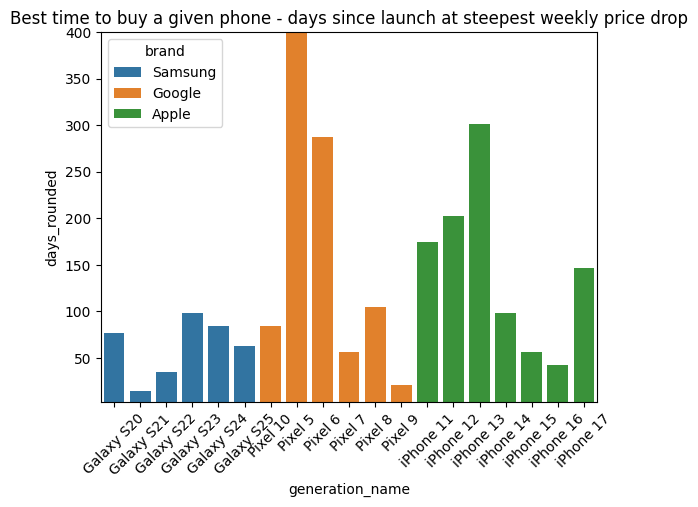

In [10]:
'''### Task 2 — Best time to buy: steepest weekly price drop per generation [3 pts]

This finds when each generation's price falls fastest — i.e. the best buying window.

1. Start from the resampled `df` (already weekly per ASIN after pipeline)
2. Compute weekly price diff per ASIN:
   ```python
   df['weekly_drop'] = df.groupby('asin')['NEW'].diff()
   ```
   (negative = price fell that week)
3. Groupby `generation_name + days_rounded` → mean `weekly_drop`
4. For each generation, find the `days_rounded` value with the most negative mean drop
   ```python
   best_time = decay_df.loc[decay_df.groupby('generation_name')['weekly_drop'].idxmin()]
   ```
5. Pull `brand` onto the result
6. Plot: Seaborn barplot, x = `generation_name`, y = `days_rounded` at steepest drop,
   hue = `brand`, sorted by `days_rounded` ascending
   Title: "Days Since Launch at Steepest Weekly Price Drop"
7. Markdown cell: when should you buy? Is there a consistent pattern per brand?'''


df['weekly_price_diff'] = df.groupby('asin')['NEW'].diff()
df['weekly_price_diff'] = df['weekly_price_diff'].fillna(0)

grouped_df = df.groupby(['generation_name', 'days_rounded'])['weekly_price_diff'].agg('mean').reset_index()
best_time_to_buy = grouped_df.loc[grouped_df.groupby('generation_name')['weekly_price_diff'].idxmin()]

brand_lookup = df[['generation_name', 'brand']].drop_duplicates()
best_time_to_buy = best_time_to_buy.merge(brand_lookup, how = 'left', on = 'generation_name')
best_time_to_buy.head()

best_time_barplot = sns.barplot(
    best_time_to_buy,
    x = 'generation_name',
    y = 'days_rounded',
    hue = 'brand'
)
best_time_barplot.set_title('Best time to buy a given phone - days since launch at steepest weekly price drop')
plt.xticks(rotation = 45)
plt.ylim(3, 400)
plt.show()



I'm not sure as these steepest weeks differ and for Pixel 10 it's very far away. Perhaps it woudl also make sense to add median/mean lines for each brand, or a different chart, maybe a boxplot or something.




In [21]:

total_price_records = len(df)
brands_covered = len(df['brand'].unique())
generations_tracked = df['generation_name'].nunique()
date_range = (df['datetime'].min(), df['datetime'].max())
apple_avg_retention = apple_retention
samsung_avg_retention = samsung_retention
google_avg_retention = google_retention
renewed_price_premium = renewed_premium_premium


from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=4,
    specs=[[{'type': 'indicator'}] * 4] * 2
)

fig.add_trace(go.Indicator(mode='number', value=total_price_records,
    title={'text': 'Price records'}), row=1, col=1)

fig.add_trace(go.Indicator(mode='number', value=brands_covered,
    title={'text': 'Brands'}), row=1, col=2)

fig.add_trace(go.Indicator(mode='number', value=generations_tracked,
    title={'text': 'Generations'}), row=1, col=3)

fig.add_trace(go.Indicator(mode='number', value=6,
    title={'text': 'Yrs of data'}), row=1, col=4)

fig.add_trace(go.Indicator(mode='number', value=apple_avg_retention,
    title={'text': 'Apple 1yr retention %'}), row=2, col=1)

fig.add_trace(go.Indicator(mode='number', value=samsung_avg_retention,
    title={'text': 'Samsung 1yr retention %'}), row=2, col=2)

fig.add_trace(go.Indicator(mode='number', value=google_avg_retention,
    title={'text': 'Google 1yr retention %'}), row=2, col=3)

fig.add_trace(go.Indicator(mode='number', value=renewed_price_premium,
    title={'text': 'Renewed Premium premium (pp)'}), row=2, col=4)

fig.update_layout(title_text='Project KPI Summary', height=400)
fig.update_layout(
    title_text='Project KPI Summary',
    height=500,
    font=dict(size=10)
)
fig.show()